In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
import pandas as pd
from kneed import KneeLocator

In [2]:
data = make_classification(n_features=10,n_informative=4)

In [3]:
X = data[0]
y = data[1]

In [4]:
cols = [f"x_{i}" for i in range(X.shape[1])] + ["y"]
df = pd.DataFrame(np.hstack([X,y.reshape(-1,1)]),
                 columns=cols)

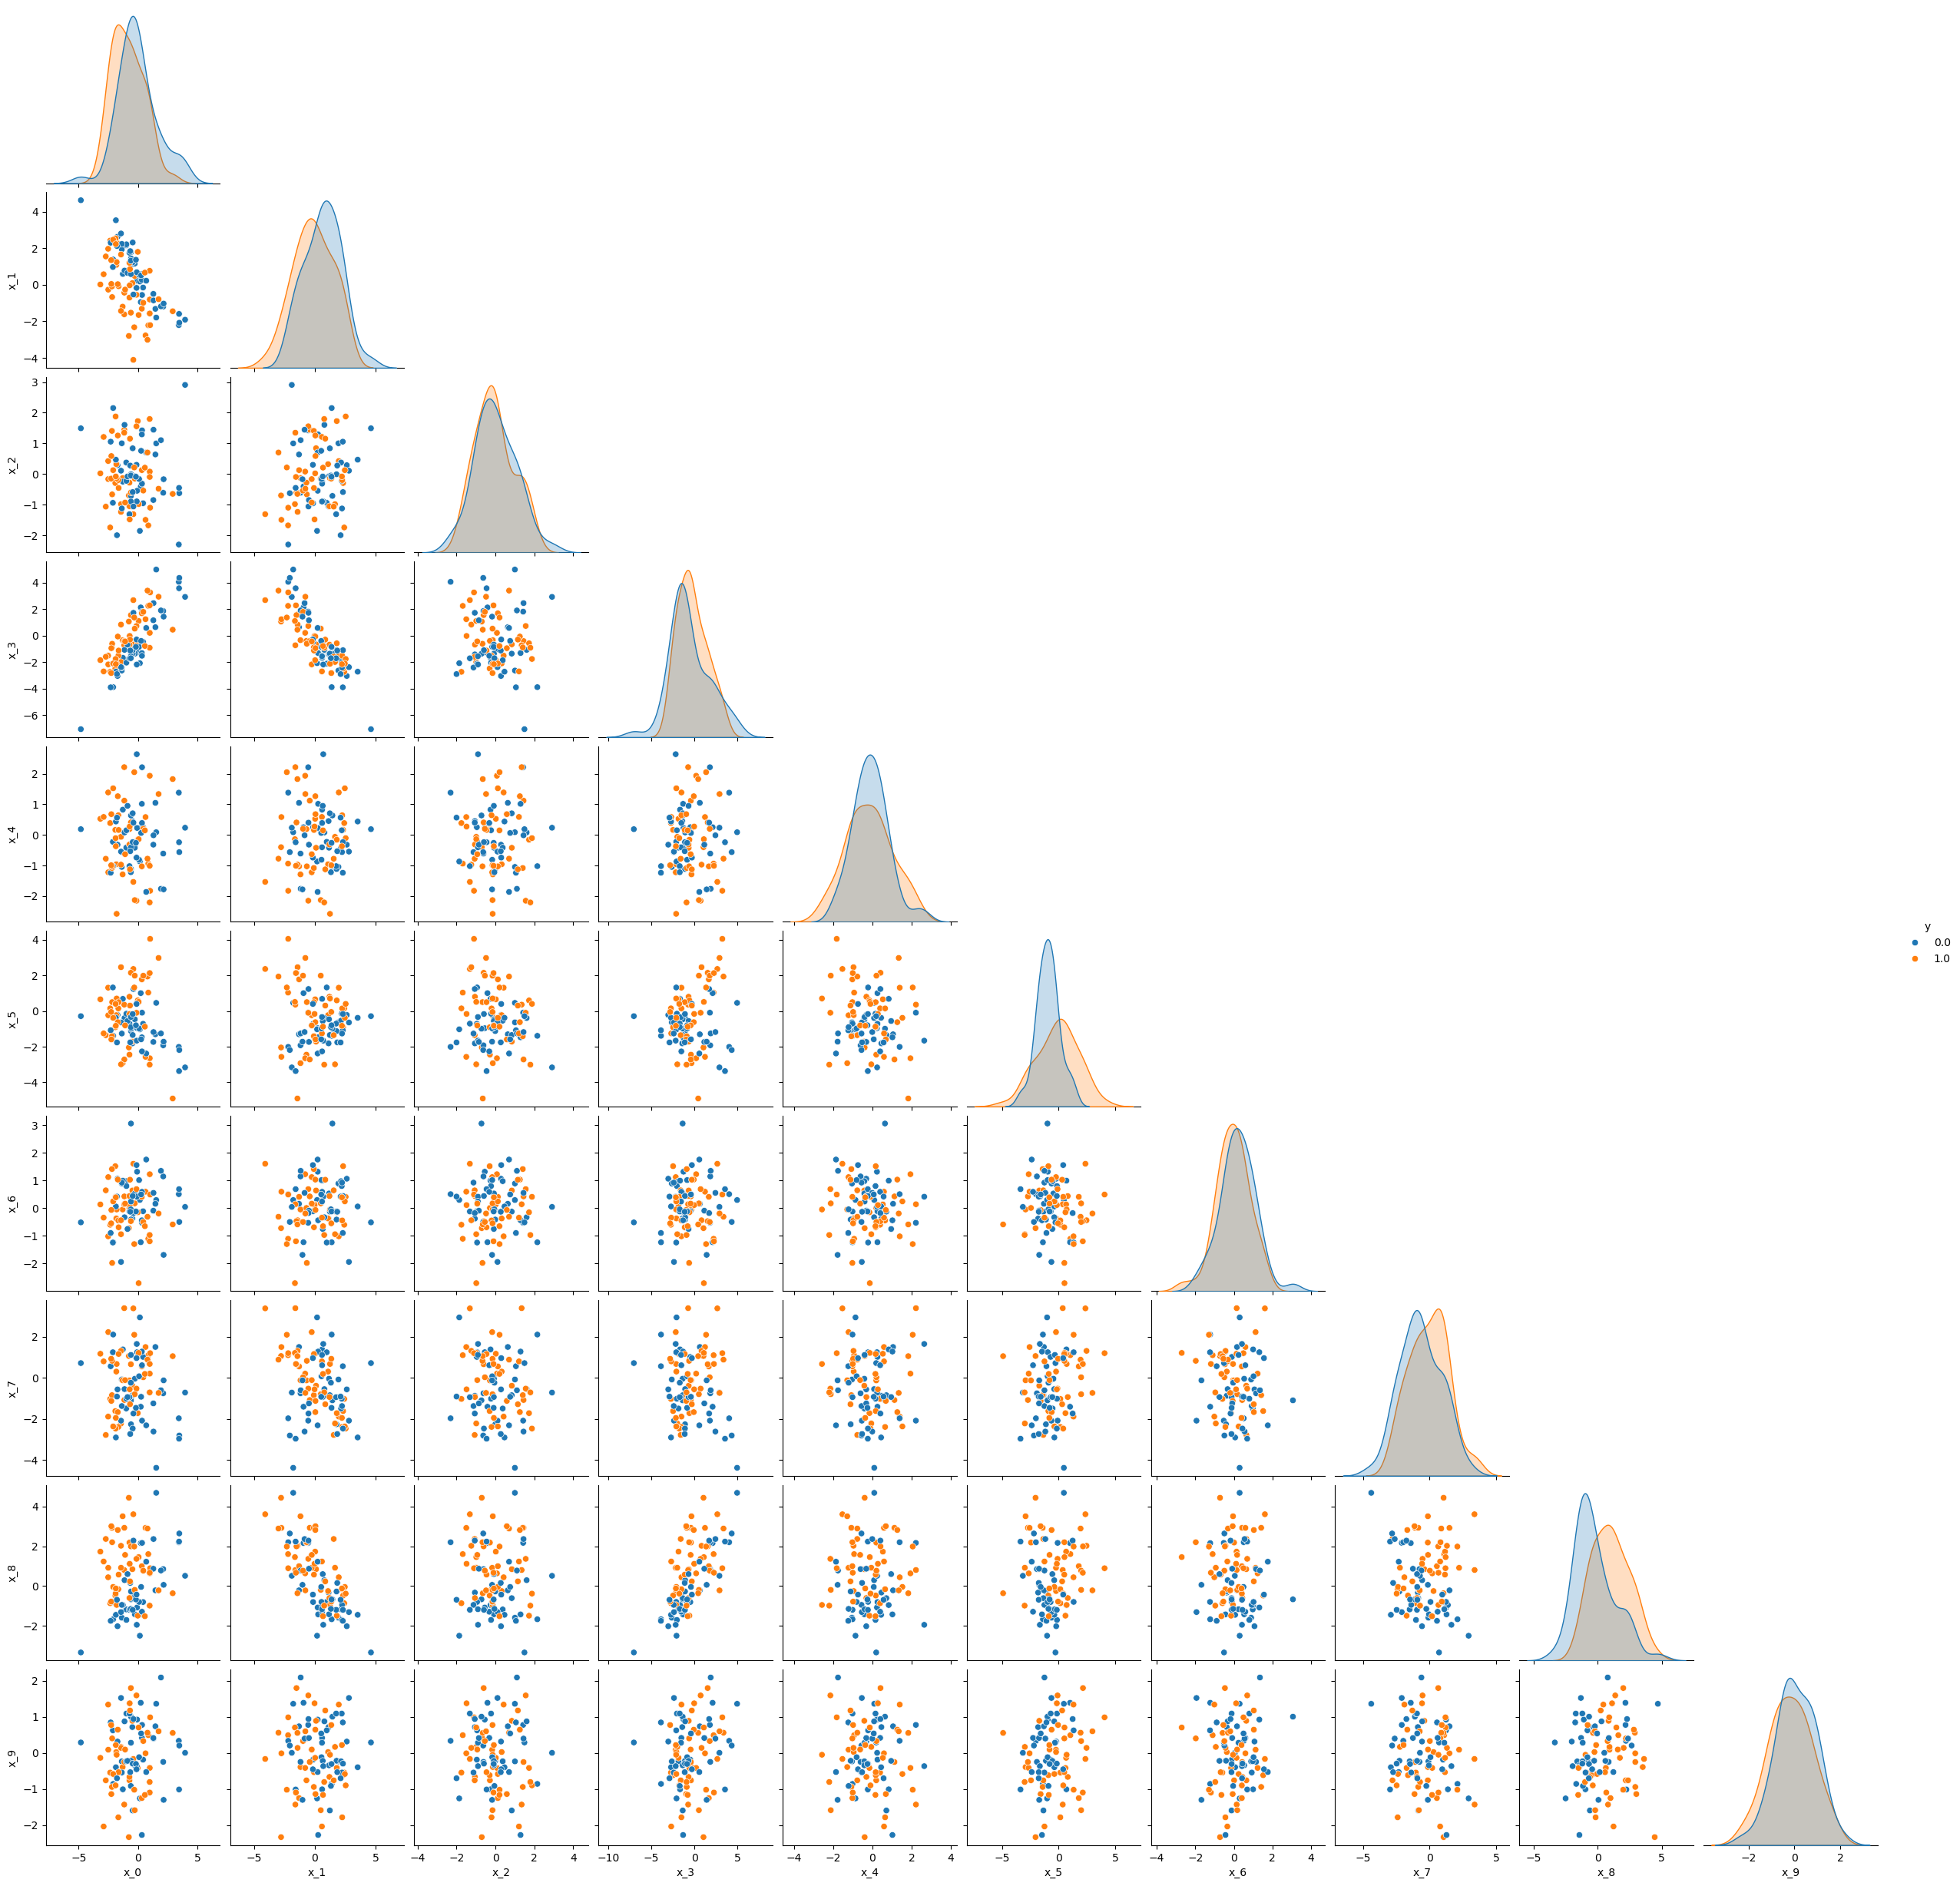

In [5]:
import seaborn as sns

sns.pairplot(df,hue="y",corner=True)

In [6]:
scaler = StandardScaler()
Xs = scaler.fit_transform(X)


In [7]:
pca = PCA().fit(Xs)

In [8]:
# autovalores
eigvals = pca.explained_variance_
# autovectores
eigvecs = pca.components_

# Técnica del codo

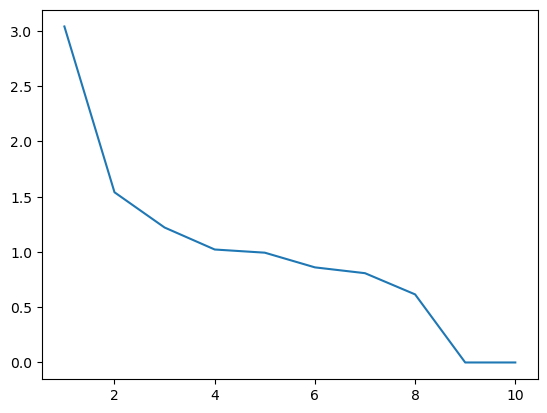

In [9]:
# técnica del codo
plt.plot([*range(1,len(eigvals)+1)],eigvals)

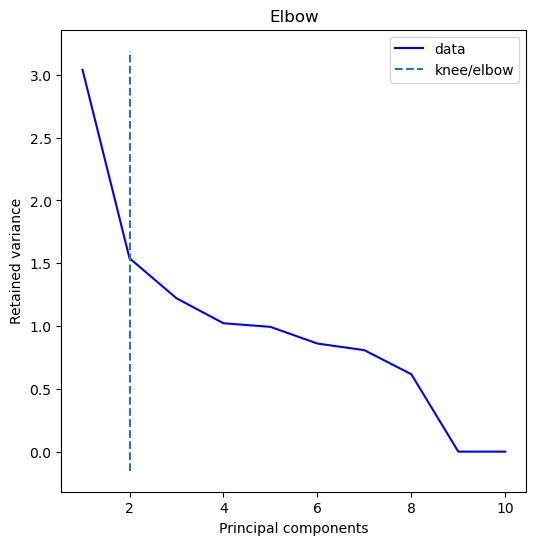

In [10]:
kl = KneeLocator( [*range(1,len(eigvals)+1)],eigvals, curve="convex", direction="decreasing")
kl.plot_knee(title="Elbow",xlabel="Principal components",ylabel="Retained variance")

In [11]:
# Nos quedamos con 2, que es lo que se veía y lo que nos da kneelocator
ndim_elbow = kl.knee
print(ndim_elbow)

2


# Varianza acumulada

In [12]:
cum_exp_var = pca.explained_variance_ratio_.cumsum()
threshold = 0.9
mask = cum_exp_var > threshold
ndim_cum = np.arange(1,len(eigvals)+1)[mask].min()
print(ndim_cum)

7


Text(0, 0.5, 'Sum of retained variance')

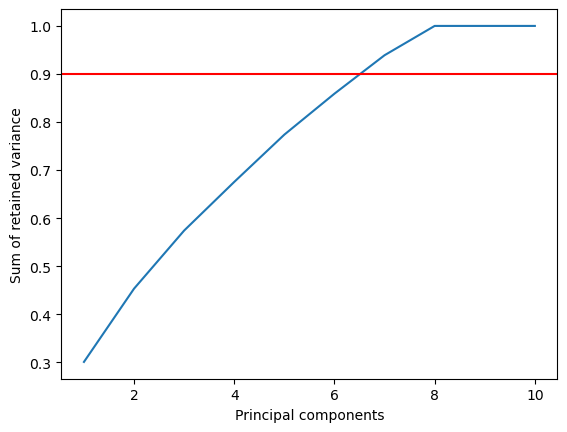

In [13]:
plt.plot([*range(1,len(eigvals)+1)],np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.9,c="red")
plt.xlabel("Principal components")
plt.ylabel("Sum of retained variance")

# Kaiser

In [14]:
ndim_kaiser = (eigvals > 1).sum()
print(ndim_kaiser)

4


# Relaciones entre las variables

In [15]:
print("Elbow")
pca_elbow = PCA(n_components=ndim_elbow).fit(Xs)
for i,c in enumerate(pca_elbow.components_):
    print(f"component {i} = ", end=" ")
    for j,cc in enumerate(c):
        print(f" {round(cc,3)}*x_{j}", end="")
        if j != len(c)-1:
            print(f" +", end="")
    print()

print("Sum of retained variance")
pca_cum = PCA(n_components=ndim_cum).fit(Xs)
for i,c in enumerate(pca_cum.components_):
    print(f"component {i} = ", end=" ")
    for j,cc in enumerate(c):
        print(f" {round(cc,3)}*x_{j}", end="")
        if j != len(c)-1:
            print(f" +", end="")
    print()

print("Kaiser")    
pca_kaiser = PCA(n_components=ndim_kaiser).fit(Xs)
for i,c in enumerate(pca_kaiser.components_):
    print(f"component {i} = ", end=" ")
    for j,cc in enumerate(c):
        print(f" {round(cc,3)}*x_{j}", end="")
        if j != len(c)-1:
            print(f" +", end="")
    print()

Elbow
component 0 =   0.43*x_0 + -0.54*x_1 + -0.105*x_2 + 0.558*x_3 + 0.008*x_4 + 0.051*x_5 + -0.017*x_6 + 0.03*x_7 + 0.43*x_8 + 0.109*x_9
component 1 =   -0.278*x_0 + -0.161*x_1 + -0.303*x_2 + -0.069*x_3 + -0.148*x_4 + 0.576*x_5 + -0.331*x_6 + 0.58*x_7 + -0.03*x_8 + 0.013*x_9
Sum of retained variance
component 0 =   0.43*x_0 + -0.54*x_1 + -0.105*x_2 + 0.558*x_3 + 0.008*x_4 + 0.051*x_5 + -0.017*x_6 + 0.03*x_7 + 0.43*x_8 + 0.109*x_9
component 1 =   -0.278*x_0 + -0.161*x_1 + -0.303*x_2 + -0.069*x_3 + -0.148*x_4 + 0.576*x_5 + -0.331*x_6 + 0.58*x_7 + -0.03*x_8 + 0.013*x_9
component 2 =   -0.07*x_0 + 0.196*x_1 + -0.033*x_2 + 0.097*x_3 + -0.371*x_4 + 0.386*x_5 + 0.111*x_6 + -0.415*x_7 + 0.003*x_8 + 0.689*x_9
component 3 =   -0.106*x_0 + 0.099*x_1 + -0.084*x_2 + 0.008*x_3 + 0.724*x_4 + 0.056*x_5 + -0.553*x_6 + -0.252*x_7 + 0.112*x_8 + 0.25*x_9
component 4 =   -0.178*x_0 + -0.042*x_1 + 0.753*x_2 + 0.052*x_3 + -0.276*x_4 + 0.129*x_5 + -0.418*x_6 + -0.115*x_7 + 0.275*x_8 + -0.202*x_9
component 5